In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import efficient_su2
from qiskit_algorithms import VQD
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit.quantum_info.analysis import Z2Symmetries

from scatterer import scatterer
from struc_const import G_AB
from functions import secular_matrix, interpolation, potential

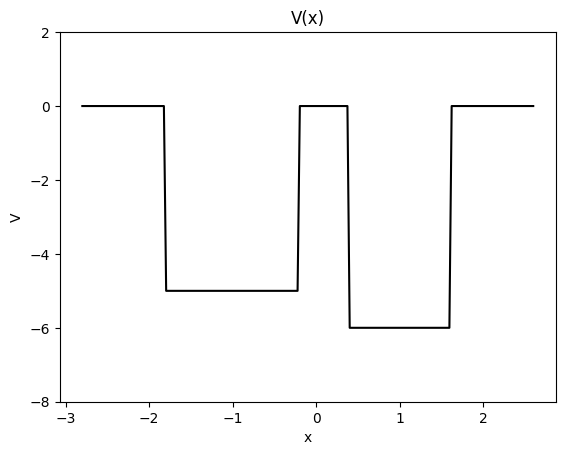

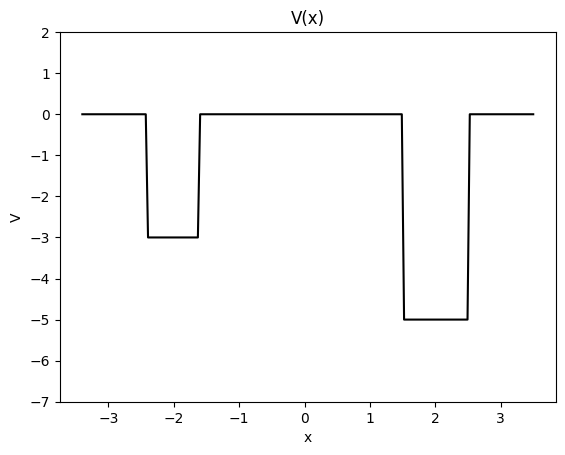

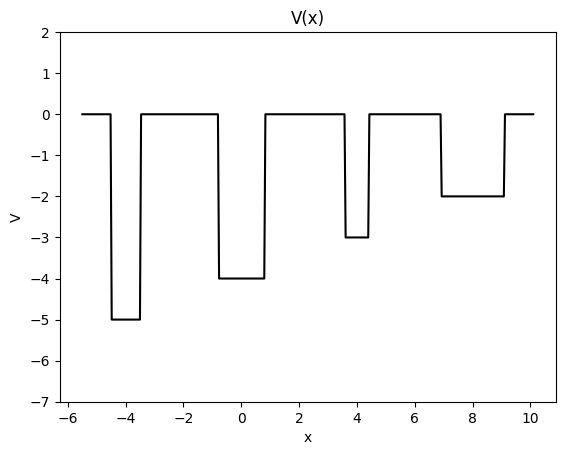

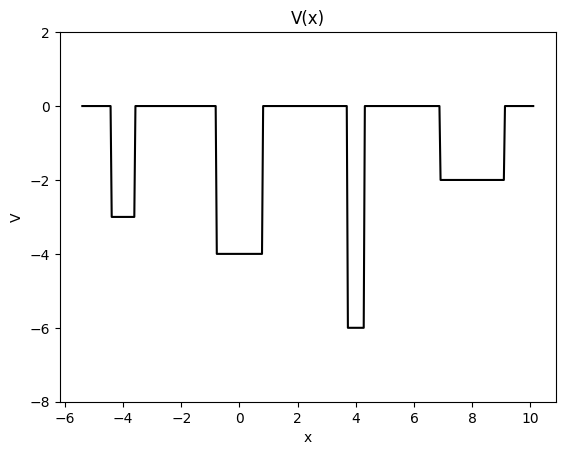

,0,1,2,3
0,-0.56607+0.00000j,-0.209752+0.000000j,7.326211e-11-9.925068e- 19j,0.038768-0.000000j


,0,1,2,3
0,-6.214126+0.000000j,-1.518371+0.000000j,0.163157+0.000000j,0.835737+0.000000j


,0,1,2,3,4,5,6,7
0,-6.214126-0.000000j,-1.518371-0.000000j,-0.303053-0.000000j,-0.177753+0.000000j,0.083176+0.000000j,0.122183-0.000000j,0.163159+0.000000j,0.835737-0.000000j


,0,1,2,3,4,5,6,7
0,-7.507156-0.000000j,-6.214126-0.000000j,-0.303053-0.000000j,-0.177753+0.000000j,0.083177-0.000000j,0.122182-0.000000j,0.360925-0.000000j,0.835737-0.000000j


In [2]:
#Example matrices
energy = -3.949901757

s1 = scatterer(0.5, -5)
s2 = scatterer(0.8, -4)
s3 = scatterer(0.4, -3)
s4 = scatterer(1.1, -2)
s5 = scatterer(0.3, -6)

rA = 0.8
VA = -5
xA = -1
rB = 0.6
VB = -6
RAB = 2

sa = scatterer(r=rA, V=VA)
sb = scatterer(rB, VB)
s = [sa, sb]
tab_x = [xA, xA+RAB]
matrix1 = secular_matrix(s, G_AB(energy, positions=tab_x), save = False)
V = potential(scatterers=s, positions=tab_x)

s = [s3, s1]
tab_x = [-2, 2]
matrix2 = secular_matrix(s, G_AB(energy, positions=tab_x), save = False)
V = potential(scatterers=s, positions=tab_x)

s = [s1, s2, s3, s4]
tab_x = [-4, 0, 4, 8]
matrix3 = secular_matrix(s, G_AB(energy, positions=tab_x), save = False)
V = potential(scatterers=s, positions=tab_x)

s = [s3, s2, s5, s4]
tab_x = [-4, 0, 4, 8]
matrix4 = secular_matrix(s, G_AB(energy, positions=tab_x), save = False)
V = potential(scatterers=s, positions=tab_x)

m = [matrix1, matrix2, matrix3, matrix4]

ev1 = np.sort(np.linalg.eigvals(matrix1))
ev2 = np.sort(np.linalg.eigvals(matrix2))
ev3 = np.sort(np.linalg.eigvals(matrix3))
ev4 = np.sort(np.linalg.eigvals(matrix4))

display(pd.DataFrame(ev1).T, pd.DataFrame(ev2).T, pd.DataFrame(ev3).T, pd.DataFrame(ev4).T)

In [3]:
df1 = pd.DataFrame(matrix1)
df2 = pd.DataFrame(matrix2)
df3 = pd.DataFrame(matrix3)
df4 = pd.DataFrame(matrix4)
display(df1, df2, df3, df4)

,0,1,2,3
0,0.024277+0.000000j,0.000000+0.000000j,-0.018782-0.000000j,-0.000000-0.018782j
1,0.000000+0.000000j,-0.212329+0.000000j,-0.000000+0.018782j,-0.018782-0.000000j
2,-0.018782-0.000000j,-0.000000+0.018782j,0.016669+0.000000j,0.000000+0.000000j
3,-0.000000-0.018782j,-0.018782-0.000000j,0.000000+0.000000j,-0.565670+0.000000j


,0,1,2,3
0,0.835737+0.000000j,0.000000+0.000000j,-0.000353-0.000000j,-0.000000-0.000353j
1,0.000000+0.000000j,-6.214126+0.000000j,-0.000000+0.000353j,-0.000353-0.000000j
2,-0.000353-0.000000j,-0.000000+0.000353j,0.163157+0.000000j,0.000000+0.000000j
3,-0.000000-0.000353j,-0.000353-0.000000j,0.000000+0.000000j,-1.518371+0.000000j


,0,1,2,3,4,5,6,7
0,1.631573e-01+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-0.000000e+00-3.527525e- 04j,-1.244343e-07-0.000000e+ 00j,-0.000000e+00-1.244343e- 07j,-4.389452e-11-0.000000e+ 00j,-0.000000e+00-4.389452e- 11j
1,0.000000e+00+0.000000e+ 00j,-1.518371e+00+0.000000e+ 00j,-0.000000e+00+3.527525e- 04j,-3.527525e-04-0.000000e+ 00j,-0.000000e+00+1.244343e- 07j,-1.244343e-07-0.000000e+ 00j,-0.000000e+00+4.389452e- 11j,-4.389452e-11-0.000000e+ 00j
2,-3.527525e-04-0.000000e+ 00j,-0.000000e+00+3.527525e- 04j,8.317758e-02+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-0.000000e+00-3.527525e- 04j,-1.244343e-07-0.000000e+ 00j,-0.000000e+00-1.244343e- 07j
3,-0.000000e+00-3.527525e- 04j,-3.527525e-04-0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-3.030536e-01+0.000000e+ 00j,-0.000000e+00+3.527525e- 04j,-3.527525e-04-0.000000e+ 00j,-0.000000e+00+1.244343e- 07j,-1.244343e-07-0.000000e+ 00j
4,-1.244343e-07-0.000000e+ 00j,-0.000000e+00+1.244343e- 07j,-3.527525e-04-0.000000e+ 00j,-0.000000e+00+3.527525e- 04j,8.357367e-01+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-0.000000e+00-3.527525e- 04j
5,-0.000000e+00-1.244343e- 07j,-1.244343e-07-0.000000e+ 00j,-0.000000e+00-3.527525e- 04j,-3.527525e-04-0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-6.214126e+00+0.000000e+ 00j,-0.000000e+00+3.527525e- 04j,-3.527525e-04-0.000000e+ 00j
6,-4.389452e-11-0.000000e+ 00j,-0.000000e+00+4.389452e- 11j,-1.244343e-07-0.000000e+ 00j,-0.000000e+00+1.244343e- 07j,-3.527525e-04-0.000000e+ 00j,-0.000000e+00+3.527525e- 04j,1.221829e-01+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j
7,-0.000000e+00-4.389452e- 11j,-4.389452e-11-0.000000e+ 00j,-0.000000e+00-1.244343e- 07j,-1.244343e-07-0.000000e+ 00j,-0.000000e+00-3.527525e- 04j,-3.527525e-04-0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-1.777529e-01+0.000000e+ 00j


,0,1,2,3,4,5,6,7
0,8.357367e-01+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-0.000000e+00-3.527525e- 04j,-1.244343e-07-0.000000e+ 00j,-0.000000e+00-1.244343e- 07j,-4.389452e-11-0.000000e+ 00j,-0.000000e+00-4.389452e- 11j
1,0.000000e+00+0.000000e+ 00j,-6.214126e+00+0.000000e+ 00j,-0.000000e+00+3.527525e- 04j,-3.527525e-04-0.000000e+ 00j,-0.000000e+00+1.244343e- 07j,-1.244343e-07-0.000000e+ 00j,-0.000000e+00+4.389452e- 11j,-4.389452e-11-0.000000e+ 00j
2,-3.527525e-04-0.000000e+ 00j,-0.000000e+00+3.527525e- 04j,8.317758e-02+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-0.000000e+00-3.527525e- 04j,-1.244343e-07-0.000000e+ 00j,-0.000000e+00-1.244343e- 07j
3,-0.000000e+00-3.527525e- 04j,-3.527525e-04-0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-3.030536e-01+0.000000e+ 00j,-0.000000e+00+3.527525e- 04j,-3.527525e-04-0.000000e+ 00j,-0.000000e+00+1.244343e- 07j,-1.244343e-07-0.000000e+ 00j
4,-1.244343e-07-0.000000e+ 00j,-0.000000e+00+1.244343e- 07j,-3.527525e-04-0.000000e+ 00j,-0.000000e+00+3.527525e- 04j,3.609247e-01+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-0.000000e+00-3.527525e- 04j
5,-0.000000e+00-1.244343e- 07j,-1.244343e-07-0.000000e+ 00j,-0.000000e+00-3.527525e- 04j,-3.527525e-04-0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-7.507156e+00+0.000000e+ 00j,-0.000000e+00+3.527525e- 04j,-3.527525e-04-0.000000e+ 00j
6,-4.389452e-11-0.000000e+ 00j,-0.000000e+00+4.389452e- 11j,-1.244343e-07-0.000000e+ 00j,-0.000000e+00+1.244343e- 07j,-3.527525e-04-0.000000e+ 00j,-0.000000e+00+3.527525e- 04j,1.221829e-01+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j
7,-0.000000e+00-4.389452e- 11j,-4.389452e-11-0.000000e+ 00j,-0.000000e+00-1.244343e- 07j,-1.244343e-07-0.000000e+ 00j,-0.000000e+00-3.527525e- 04j,-3.527525e-04-0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,-1.777529e-01+0.000000e+ 00j


In [4]:
def xor(matrix):
    N = matrix.shape[0]
    result = np.zeros_like(matrix, dtype=complex)
    for i in range(N):
        for j in range(N):
            result[j, i] = matrix[j^i, i]
    return result

matrix1_xor = xor(matrix1)
matrix2_xor = xor(matrix2)
matrix3_xor = xor(matrix3)
matrix4_xor = xor(matrix4)

df1 = pd.DataFrame(matrix1_xor)
df2 = pd.DataFrame(matrix2_xor)
df3 = pd.DataFrame(matrix3_xor)
df4 = pd.DataFrame(matrix4_xor)

display(df1, df2, df3, df4)

,0,1,2,3
0,0.024277+0.000000j,-0.212329+0.000000j,0.016669+0.000000j,-0.565670+0.000000j
1,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j
2,-0.018782-0.000000j,-0.018782-0.000000j,-0.018782-0.000000j,-0.018782-0.000000j
3,-0.000000-0.018782j,-0.000000+0.018782j,-0.000000+0.018782j,-0.000000-0.018782j


,0,1,2,3
0,0.835737+0.000000j,-6.214126+0.000000j,0.163157+0.000000j,-1.518371+0.000000j
1,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j
2,-0.000353-0.000000j,-0.000353-0.000000j,-0.000353-0.000000j,-0.000353-0.000000j
3,-0.000000-0.000353j,-0.000000+0.000353j,-0.000000+0.000353j,-0.000000-0.000353j


,0,1,2,3,4,5,6,7
0,1.631573e-01+0.000000e+ 00j,-1.518371e+00+0.000000e+ 00j,8.317758e-02+0.000000e+ 00j,-3.030536e-01+0.000000e+ 00j,8.357367e-01+0.000000e+ 00j,-6.214126e+00+0.000000e+ 00j,1.221829e-01+0.000000e+ 00j,-1.777529e-01+0.000000e+ 00j
1,0.000000e+00+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j
2,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j
3,-0.000000e+00-3.527525e- 04j,-0.000000e+00+3.527525e- 04j,-0.000000e+00+3.527525e- 04j,-0.000000e+00-3.527525e- 04j,-0.000000e+00-3.527525e- 04j,-0.000000e+00+3.527525e- 04j,-0.000000e+00+3.527525e- 04j,-0.000000e+00-3.527525e- 04j
4,-1.244343e-07-0.000000e+ 00j,-1.244343e-07-0.000000e+ 00j,-1.244343e-07-0.000000e+ 00j,-1.244343e-07-0.000000e+ 00j,-1.244343e-07-0.000000e+ 00j,-1.244343e-07-0.000000e+ 00j,-1.244343e-07-0.000000e+ 00j,-1.244343e-07-0.000000e+ 00j
5,-0.000000e+00-1.244343e- 07j,-0.000000e+00+1.244343e- 07j,-0.000000e+00-1.244343e- 07j,-0.000000e+00+1.244343e- 07j,-0.000000e+00+1.244343e- 07j,-0.000000e+00-1.244343e- 07j,-0.000000e+00+1.244343e- 07j,-0.000000e+00-1.244343e- 07j
6,-4.389452e-11-0.000000e+ 00j,-4.389452e-11-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-4.389452e-11-0.000000e+ 00j,-4.389452e-11-0.000000e+ 00j
7,-0.000000e+00-4.389452e- 11j,-0.000000e+00+4.389452e- 11j,-0.000000e+00-3.527525e- 04j,-0.000000e+00+3.527525e- 04j,-0.000000e+00+3.527525e- 04j,-0.000000e+00-3.527525e- 04j,-0.000000e+00+4.389452e- 11j,-0.000000e+00-4.389452e- 11j


,0,1,2,3,4,5,6,7
0,8.357367e-01+0.000000e+ 00j,-6.214126e+00+0.000000e+ 00j,8.317758e-02+0.000000e+ 00j,-3.030536e-01+0.000000e+ 00j,3.609247e-01+0.000000e+ 00j,-7.507156e+00+0.000000e+ 00j,1.221829e-01+0.000000e+ 00j,-1.777529e-01+0.000000e+ 00j
1,0.000000e+00+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j,0.000000e+00+0.000000e+ 00j
2,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j
3,-0.000000e+00-3.527525e- 04j,-0.000000e+00+3.527525e- 04j,-0.000000e+00+3.527525e- 04j,-0.000000e+00-3.527525e- 04j,-0.000000e+00-3.527525e- 04j,-0.000000e+00+3.527525e- 04j,-0.000000e+00+3.527525e- 04j,-0.000000e+00-3.527525e- 04j
4,-1.244343e-07-0.000000e+ 00j,-1.244343e-07-0.000000e+ 00j,-1.244343e-07-0.000000e+ 00j,-1.244343e-07-0.000000e+ 00j,-1.244343e-07-0.000000e+ 00j,-1.244343e-07-0.000000e+ 00j,-1.244343e-07-0.000000e+ 00j,-1.244343e-07-0.000000e+ 00j
5,-0.000000e+00-1.244343e- 07j,-0.000000e+00+1.244343e- 07j,-0.000000e+00-1.244343e- 07j,-0.000000e+00+1.244343e- 07j,-0.000000e+00+1.244343e- 07j,-0.000000e+00-1.244343e- 07j,-0.000000e+00+1.244343e- 07j,-0.000000e+00-1.244343e- 07j
6,-4.389452e-11-0.000000e+ 00j,-4.389452e-11-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-3.527525e-04-0.000000e+ 00j,-4.389452e-11-0.000000e+ 00j,-4.389452e-11-0.000000e+ 00j
7,-0.000000e+00-4.389452e- 11j,-0.000000e+00+4.389452e- 11j,-0.000000e+00-3.527525e- 04j,-0.000000e+00+3.527525e- 04j,-0.000000e+00+3.527525e- 04j,-0.000000e+00-3.527525e- 04j,-0.000000e+00+4.389452e- 11j,-0.000000e+00-4.389452e- 11j


In [5]:
def fwht(matrix):
    N = matrix.shape[0]
    res = matrix.astype(complex).copy()
    
    for r in range(N):
        h = 1
        while h < N:
            for i in range(0, N, h*2):
                for j in range(i, i+h):
                    x = res[r, j]
                    y = res[r, j + h]
                    res[r, j] = x+y
                    res[r, j+h] = x-y
            h *= 2
    return res


matrix1_hadamard = fwht(matrix1_xor)
matrix2_hadamard = fwht(matrix2_xor)
matrix3_hadamard = fwht(matrix3_xor)
matrix4_hadamard = fwht(matrix4_xor)

display(pd.DataFrame(matrix1_hadamard), pd.DataFrame(matrix2_hadamard), pd.DataFrame(matrix3_hadamard), pd.DataFrame(matrix4_hadamard))

,0,1,2,3
0,-0.737054+0.000000j,0.818946+0.000000j,0.360949+0.000000j,-0.345733+0.000000j
1,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j
2,-0.075127-0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j
3,-0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000-0.075127j


,0,1,2,3
0,-6.733603+0.000000j,8.731391+0.000000j,-4.023175+0.000000j,5.368334+0.000000j
1,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j
2,-0.001411-0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j
3,-0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000-0.001411j


,0,1,2,3,4,5,6,7
0,-7.009049e+00+0.000000e+ 00j,9.417558+0.000000j,-6.458157+0.000000j,8.045224+0.000000j,3.858869+0.000000j,-5.282039e+00+0.000000e+ 00j,4.187481+0.000000j,-5.45463+0.00000j
1,0.000000e+00+0.000000e+ 00j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000e+00+0.000000e+ 00j,0.000000+0.000000j,0.00000+0.00000j
2,-2.822020e-03-0.000000e+ 00j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000e+00+0.000000e+ 00j,0.000000+0.000000j,0.00000+0.00000j
3,-0.000000e+00+0.000000e+ 00j,0.000000+0.000000j,0.000000+0.000000j,0.000000-0.002822j,0.000000+0.000000j,0.000000e+00+0.000000e+ 00j,0.000000+0.000000j,0.00000+0.00000j
4,-9.954746e-07-0.000000e+ 00j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000e+00+0.000000e+ 00j,0.000000+0.000000j,0.00000+0.00000j
5,-0.000000e+00+0.000000e+ 00j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000e+00-9.954746e- 07j,0.000000+0.000000j,0.00000+0.00000j
6,-1.411010e-03-0.000000e+ 00j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000000e+00+0.000000e+ 00j,0.001411+0.000000j,0.00000+0.00000j
7,-0.000000e+00+0.000000e+ 00j,0.000000+0.000000j,0.000000+0.000000j,0.000000+0.001411j,0.000000+0.000000j,0.000000e+00-1.411010e- 03j,0.000000+0.000000j,0.00000+0.00000j


,0,1,2,3,4,5,6,7
0,-1.280007e+01+0.000000e+ 00j,15.604111+ 0.000000j,-12.249175+ 0.000000j,14.231777+ 0.000000j,1.603537+0.000000j,-7.319233e-01+0.000000e+ 00j,1.932149+0.000000j,-0.904514+0.000000j
1,0.000000e+00+0.000000e+ 00j,0.000000+ 0.000000j,0.000000+ 0.000000j,0.000000+ 0.000000j,0.000000+0.000000j,0.000000e+00+0.000000e+ 00j,0.000000+0.000000j,0.000000+0.000000j
2,-2.822020e-03-0.000000e+ 00j,0.000000+ 0.000000j,0.000000+ 0.000000j,0.000000+ 0.000000j,0.000000+0.000000j,0.000000e+00+0.000000e+ 00j,0.000000+0.000000j,0.000000+0.000000j
3,-0.000000e+00+0.000000e+ 00j,0.000000+ 0.000000j,0.000000+ 0.000000j,0.000000- 0.002822j,0.000000+0.000000j,0.000000e+00+0.000000e+ 00j,0.000000+0.000000j,0.000000+0.000000j
4,-9.954746e-07-0.000000e+ 00j,0.000000+ 0.000000j,0.000000+ 0.000000j,0.000000+ 0.000000j,0.000000+0.000000j,0.000000e+00+0.000000e+ 00j,0.000000+0.000000j,0.000000+0.000000j
5,-0.000000e+00+0.000000e+ 00j,0.000000+ 0.000000j,0.000000+ 0.000000j,0.000000+ 0.000000j,0.000000+0.000000j,0.000000e+00-9.954746e- 07j,0.000000+0.000000j,0.000000+0.000000j
6,-1.411010e-03-0.000000e+ 00j,0.000000+ 0.000000j,0.000000+ 0.000000j,0.000000+ 0.000000j,0.000000+0.000000j,0.000000e+00+0.000000e+ 00j,0.001411+0.000000j,0.000000+0.000000j
7,-0.000000e+00+0.000000e+ 00j,0.000000+ 0.000000j,0.000000+ 0.000000j,0.000000+ 0.001411j,0.000000+0.000000j,0.000000e+00-1.411010e- 03j,0.000000+0.000000j,0.000000+0.000000j


In [6]:
def prefactors(matrix):
    N = matrix.shape[0]
    num_qubits = int(np.log2(N))
    pauli_labels = []
    coefficients = []
    mapping = {(0, 0): 'I', (1, 0): 'X', (0, 1): 'Z', (1, 1): 'Y'}
    for r in range(N):
        for s in range(N):
            val = matrix[r, s]
            if np.abs(val) > 1e-12:
                h_weight = bin(r & s).count('1')
                alpha_rs = val * ((-1j)**h_weight) / N
                label_list = []
                for j in range(num_qubits):
                    bit_r = (r >> j) & 1
                    bit_s = (s >> j) & 1
                    label_list.append(mapping[(bit_r, bit_s)])
                label = "".join(label_list[::-1])
                pauli_labels.append(label)
                coefficients.append(alpha_rs)
    return SparsePauliOp(pauli_labels, coefficients)


pauli1_result = prefactors(matrix1_hadamard)
pauli2_result = prefactors(matrix2_hadamard)
pauli3_result = prefactors(matrix3_hadamard)
pauli4_result = prefactors(matrix4_hadamard)


df1_pauli = pd.DataFrame(pauli1_result.to_list(), columns=['Pauli String', 'Coefficient'])
df2_pauli = pd.DataFrame(pauli2_result.to_list(), columns=['Pauli String', 'Coefficient'])
df3_pauli = pd.DataFrame(pauli3_result.to_list(), columns=['Pauli String', 'Coefficient'])
df4_pauli = pd.DataFrame(pauli4_result.to_list(), columns=['Pauli String', 'Coefficient'])

display(df1_pauli, df2_pauli, df3_pauli, df4_pauli)


,Pauli String,Coefficient
0,II,-0.184263+0.000000j
1,IZ,0.204736+0.000000j
2,ZI,0.090237+0.000000j
3,ZZ,-0.086433+0.000000j
4,XI,-0.018782+0.000000j
5,YY,0.000000+0.018782j


,Pauli String,Coefficient
0,II,-1.683401+0.000000j
1,IZ,2.182848+0.000000j
2,ZI,-1.005794+0.000000j
3,ZZ,1.342084+0.000000j
4,XI,-0.000353+0.000000j
5,YY,0.000000+0.000353j


,Pauli String,Coefficient
0,III,-8.761311e-01+0.000000e+ 00j
1,IIZ,1.177195e+00+0.000000e+ 00j
2,IZI,-8.072696e-01+0.000000e+ 00j
3,IZZ,1.005653e+00+0.000000e+ 00j
4,ZII,4.823587e-01+0.000000e+ 00j
5,ZIZ,-6.602549e-01+0.000000e+ 00j
6,ZZI,5.234352e-01+0.000000e+ 00j
7,ZZZ,-6.818287e-01+0.000000e+ 00j
8,IXI,-3.527525e-04+0.000000e+ 00j
9,IYY,0.000000e+00+3.527525e- 04j


,Pauli String,Coefficient
0,III,-1.600008e+00+0.000000e+ 00j
1,IIZ,1.950514e+00+0.000000e+ 00j
2,IZI,-1.531147e+00+0.000000e+ 00j
3,IZZ,1.778972e+00+0.000000e+ 00j
4,ZII,2.004421e-01+0.000000e+ 00j
5,ZIZ,-9.149041e-02+0.000000e+ 00j
6,ZZI,2.415186e-01+0.000000e+ 00j
7,ZZZ,-1.130642e-01+0.000000e+ 00j
8,IXI,-3.527525e-04+0.000000e+ 00j
9,IYY,0.000000e+00+3.527525e- 04j


In [7]:
optimizer = COBYLA()
estimator = StatevectorEstimator()
sampler = StatevectorSampler() 
fidelity = ComputeUncompute(sampler) 


op = pauli1_result
hermitian_op = (op + op.adjoint()) / 2
ansatz = efficient_su2(hermitian_op.num_qubits, reps=5)
vqd = VQD(estimator, fidelity, ansatz, optimizer, k=4)
result = vqd.compute_eigenvalues(hermitian_op)
ev_vqd = np.sort(result.eigenvalues.real)
ev_num = np.sort(np.real(np.linalg.eigvals(matrix1)))

df_compare = pd.DataFrame([ev_num, ev_vqd], index=['NumPy', 'VQD'])
display(df_compare)

,0,1,2,3
NumPy,-0.566070,-0.209752,7.326211e-11,0.038768
VQD,-0.566666,-0.160585,-1.929599e-02,0.001852


In [8]:
op = pauli2_result
hermitian_op = (op + op.adjoint()) / 2
ansatz = efficient_su2(hermitian_op.num_qubits, reps=3)
vqd = VQD(estimator, fidelity, ansatz, optimizer, k=4)
result = vqd.compute_eigenvalues(hermitian_op)
ev_vqd = np.sort(result.eigenvalues.real)
ev_num = np.sort(np.real(np.linalg.eigvals(matrix2)))

df_compare = pd.DataFrame([ev_num, ev_vqd], index=['NumPy', 'VQD'])
display(df_compare)

,0,1,2,3
NumPy,-6.214126,-1.518371,0.163157,0.835737
VQD,-6.214126,-1.358512,0.340784,0.428503


In [9]:
op = pauli3_result
hermitian_op = (op + op.adjoint()) / 2
ansatz = efficient_su2(hermitian_op.num_qubits, reps=3)
vqd = VQD(estimator, fidelity, ansatz, optimizer, k=8)
result = vqd.compute_eigenvalues(hermitian_op)
ev_vqd = np.sort(result.eigenvalues.real)
ev_num = np.sort(np.real(np.linalg.eigvals(matrix3)))

df_compare = pd.DataFrame([ev_num, ev_vqd], index=['NumPy', 'VQD'])
display(df_compare)

,0,1,2,3,4,5,6,7
NumPy,-6.214126,-1.518371,-0.303053,-0.177753,0.083176,0.122183,0.163159,0.835737
VQD,-6.214126,-0.562271,-0.429748,-0.033560,-0.028226,-0.008711,0.015777,0.027378


In [10]:
op = pauli4_result
hermitian_op = (op + op.adjoint()) / 2
ansatz = efficient_su2(hermitian_op.num_qubits, reps=3)
vqd = VQD(estimator, fidelity, ansatz, optimizer, k=8)
result = vqd.compute_eigenvalues(hermitian_op)
ev_vqd = np.sort(result.eigenvalues.real)
ev_num = np.sort(np.real(np.linalg.eigvals(matrix4)))

df_compare = pd.DataFrame([ev_num, ev_vqd], index=['NumPy', 'VQD'])
display(df_compare)

,0,1,2,3,4,5,6,7
NumPy,-7.507156,-6.214126,-0.303053,-0.177753,0.083177,0.122182,0.360925,0.835737
VQD,-7.507156,-4.007144,-0.854023,-0.528357,-0.397604,-0.363521,-0.309775,-0.040498
